In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("./air_quality.csv")

print(df.head())
print(df.info())

        City    Datetime  PM2.5   PM10     NO   NO2    NOx   NH3    CO   SO2  \
0      Delhi  2015-01-01  153.3  241.7  182.9  33.0   81.3  38.5  1.87  64.5   
1     Mumbai  2015-01-01   70.5  312.7  195.0  42.0  122.5  31.5  7.22  83.8   
2    Chennai  2015-01-01  174.1  275.4   56.2  68.8  230.9  28.5  8.56  60.8   
3    Kolkata  2015-01-01  477.2  543.9   14.1  76.4  225.9  45.6  2.41  42.1   
4  Bangalore  2015-01-01  171.6  117.7  123.3  12.4   61.9  49.7  1.26  79.7   

      O3  Benzene  Toluene  Xylene    AQI    AQI_Bucket  
0   83.6    18.93    20.81    8.32  204.5        Severe  
1  108.0     2.01    19.41    2.86   60.9  Satisfactory  
2   43.9    19.07    10.19    9.63  486.5        Severe  
3  171.1     9.31    11.65    9.39  174.4     Very Poor  
4  164.3     6.04    12.74    9.59  489.7          Good  
<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      -------------- 

In [2]:
df['AQI'] = (
    0.5 * df['PM2.5'] +
    0.3 * df['PM10'] +
    0.1 * df['NO2'] +
    0.05 * df['SO2'] +
    0.05 * df['CO']
)

In [3]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Bucket'] = df['AQI'].apply(categorize_aqi)

In [4]:
# Convert date
df['Date'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Extract useful features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Remove duplicates
df = df.drop_duplicates()

# Strip column names
df.columns = df.columns.str.strip()

# Handle missing values (BETTER than mean)
df = df.ffill()
df = df.bfill()

# Final null check
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Date          0
Year          0
Month         0
dtype: int64


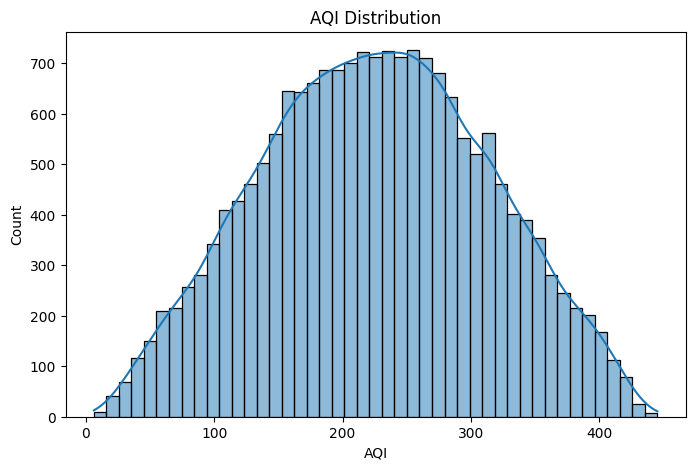

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], kde=True)
plt.title("AQI Distribution")
plt.show()

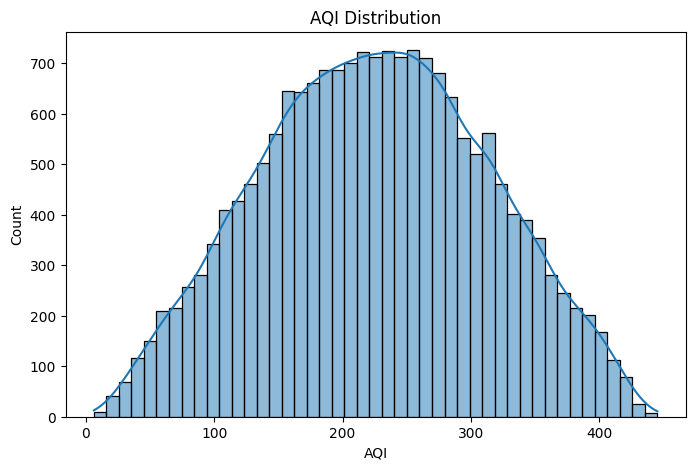

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], kde=True)
plt.title("AQI Distribution")
plt.show()

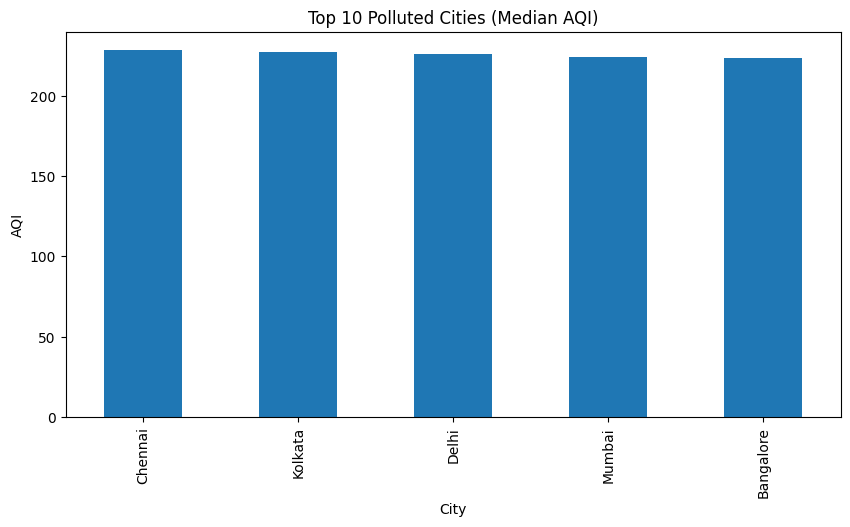

In [7]:
city_aqi = df.groupby('City')['AQI'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
city_aqi.plot(kind='bar')
plt.title("Top 10 Polluted Cities (Median AQI)")
plt.ylabel("AQI")
plt.show()

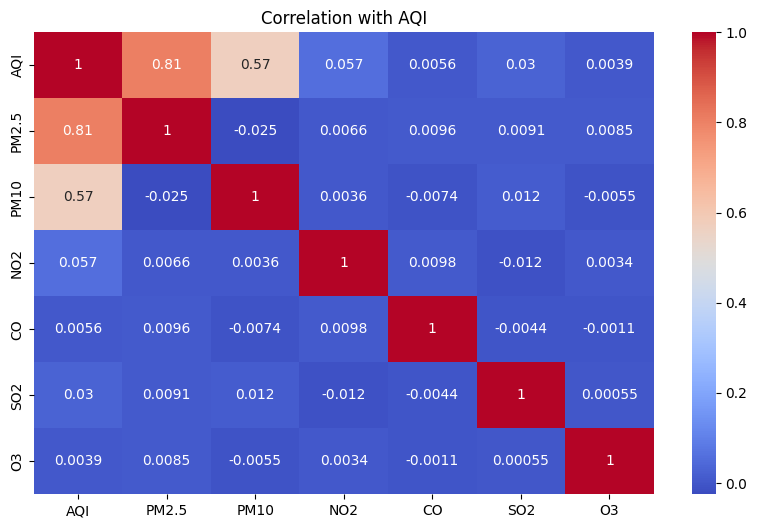

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['AQI','PM2.5','PM10','NO2','CO','SO2','O3']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation with AQI")
plt.show()

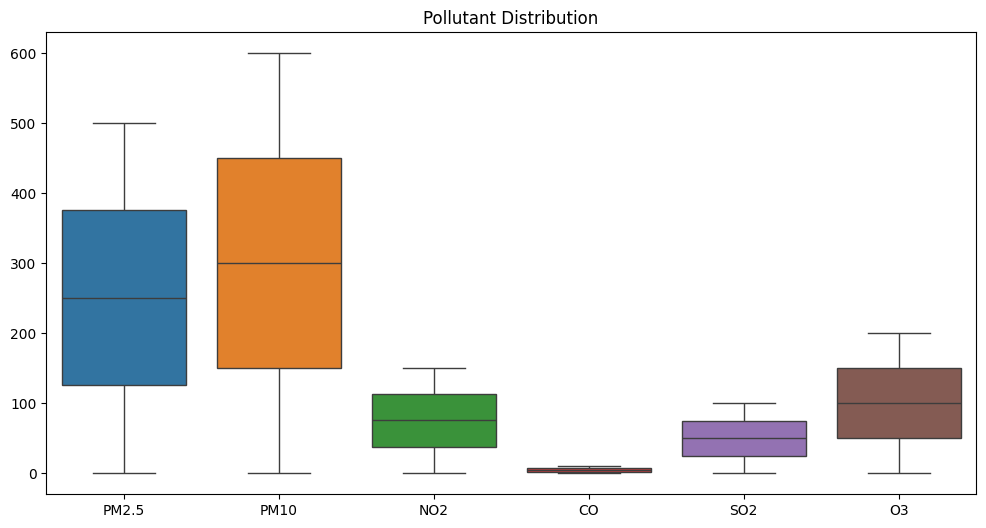

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['PM2.5','PM10','NO2','CO','SO2','O3']])
plt.title("Pollutant Distribution")
plt.show()

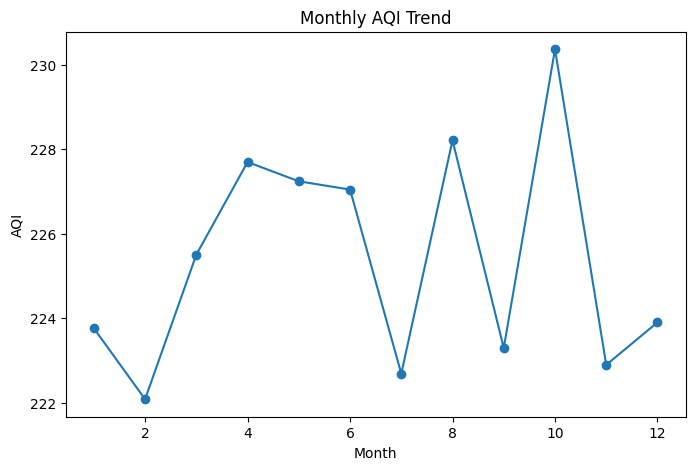

In [10]:
monthly = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
monthly.plot(marker='o')
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

In [11]:
print("\nCorrelation with AQI:\n")
print(df.corr(numeric_only=True)['AQI'].sort_values(ascending=False))


Correlation with AQI:

AQI        1.000000
PM2.5      0.805284
PM10       0.570456
NO2        0.056670
SO2        0.030102
CO         0.005582
NH3        0.005100
O3         0.003877
Month      0.002556
Xylene     0.001313
Benzene    0.001108
NOx       -0.000500
Toluene   -0.001174
NO        -0.001346
Year      -0.004518
Name: AQI, dtype: float64


In [12]:
# Features (input)
X = df[['PM2.5','PM10','NO2','CO','SO2','O3']]

# Target for regression
y_reg = df['AQI']

# Target for classification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_clf = le.fit_transform(df['AQI_Bucket'])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
dt = DecisionTreeRegressor()

lr.fit(X_train, y_train_reg)
rf.fit(X_train, y_train_reg)
dt.fit(X_train, y_train_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Decision Tree": dt
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test_reg, y_pred))
    print("R2:", r2_score(y_test_reg, y_pred))


Linear Regression
MAE: 6.164196506699516e-14
R2: 1.0

Random Forest
MAE: 1.9012340925266902
R2: 0.9992504478797407

Decision Tree
MAE: 3.7034130851355047
R2: 0.9972074779008785


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
lr_clf = LogisticRegression(max_iter=1000)
dt_clf = DecisionTreeClassifier()

rf_clf.fit(X_train, y_train_clf)
lr_clf.fit(X_train, y_train_clf)
dt_clf.fit(X_train, y_train_clf)

c:\Users\hp\AQI-Prediction-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [17]:
from sklearn.metrics import accuracy_score, classification_report

clf_models = {
    "Random Forest": rf_clf,
    "Logistic Regression": lr_clf,
    "Decision Tree": dt_clf
}

for name, model in clf_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_clf, y_pred))
    print(classification_report(y_test_clf, y_pred))


Random Forest
Accuracy: 0.9712565015056118
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        56
           1       0.96      0.98      0.97      1092
           2       0.98      0.98      0.98      1460
           3       0.95      0.91      0.93       243
           4       1.00      0.91      0.95        79
           5       0.98      0.98      0.98       723

    accuracy                           0.97      3653
   macro avg       0.97      0.94      0.95      3653
weighted avg       0.97      0.97      0.97      3653


Logistic Regression
Accuracy: 0.7265261428962496
              precision    recall  f1-score   support

           0       0.72      0.70      0.71        56
           1       0.74      0.78      0.76      1092
           2       0.72      0.82      0.77      1460
           3       0.66      0.40      0.50       243
           4       0.00      0.00      0.00        79
           5       0.72      0.65     

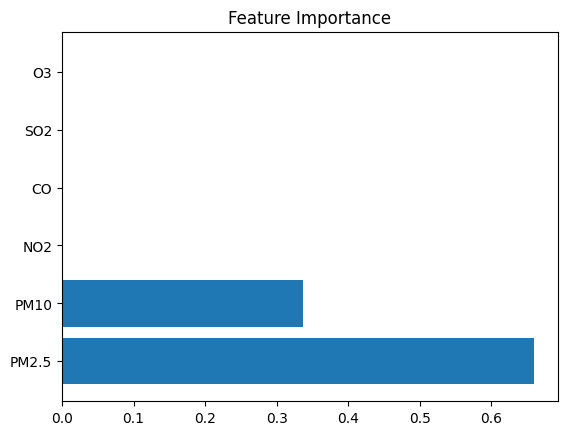

In [18]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
# FEATURES
X = df[['PM2.5','PM10','NO2','CO','SO2','O3']]
y = df['AQI']

# SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL 1: Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# MODEL 2: Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# MODEL 3: Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
# EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

from sklearn.metrics import mean_absolute_error, r2_score

print("\nDecision Tree:")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))

print("R2:", r2_score(y_test, y_pred_dt))

Linear Regression:
MAE: 6.164196506699516e-14
R2: 1.0

Random Forest:
MAE: 1.8848896865589937
R2: 0.9992620704413097
Decision Tree:
MAE: 3.690167670407883
R2: 0.9972413708208164


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['AQI_Bucket_encoded'] = le.fit_transform(df['AQI_Bucket'])

In [21]:
X = df[['PM2.5','PM10','NO2','CO','SO2','O3']]
y = df['AQI_Bucket_encoded']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.9696140158773611

Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93        56
           1       0.96      0.97      0.97      1092
           2       0.97      0.98      0.98      1460
           3       0.96      0.91      0.93       243
           4       0.99      0.87      0.93        79
           5       0.98      0.98      0.98       723

    accuracy                           0.97      3653
   macro avg       0.97      0.93      0.95      3653
weighted avg       0.97      0.97      0.97      3653



In [24]:
importances = rf.feature_importances_

for i,v in zip(X.columns, importances):
    print(i, ":", v)

PM2.5 : 0.6594960312676079
PM10 : 0.33810766459404046
NO2 : 0.0018020339283032203
CO : 0.00016444805410213977
SO2 : 0.0002593052913834561
O3 : 0.00017051686456271027


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y_reg, cv=5, scoring='r2')

print("Cross Validation R2 Scores:", scores)
print("Average R2:", scores.mean())

Cross Validation R2 Scores: [0.99927823 0.99926501 0.99929933 0.99925872 0.99925523]
Average R2: 0.9992713036203552


In [26]:
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R2": r2_score(y_test_reg, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model           MAE        R2
0  Linear Regression  6.164197e-14  1.000000
1      Random Forest  1.901234e+00  0.999250
2      Decision Tree  3.703413e+00  0.997207


In [27]:
y_pred_clf = rf_clf.predict(X_test)

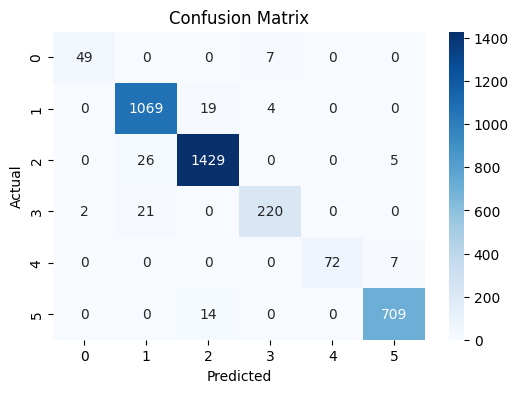

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Axes: >

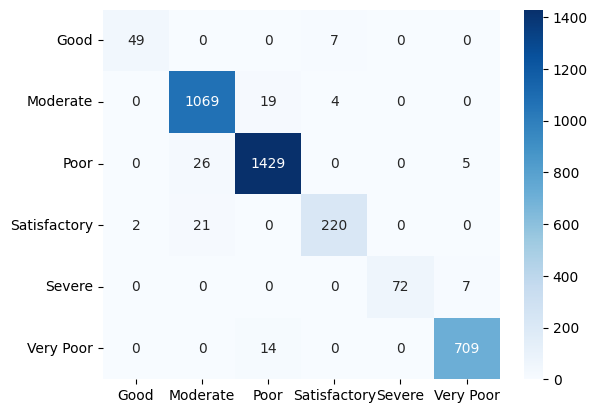

In [29]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

In [30]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train_clf)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}


In [ ]:
import pickle

In [ ]:
pickle.dump(rf, open("regressor.pkl", "wb"))

In [ ]:
pickle.dump(clf, open("classifier.pkl", "wb"))

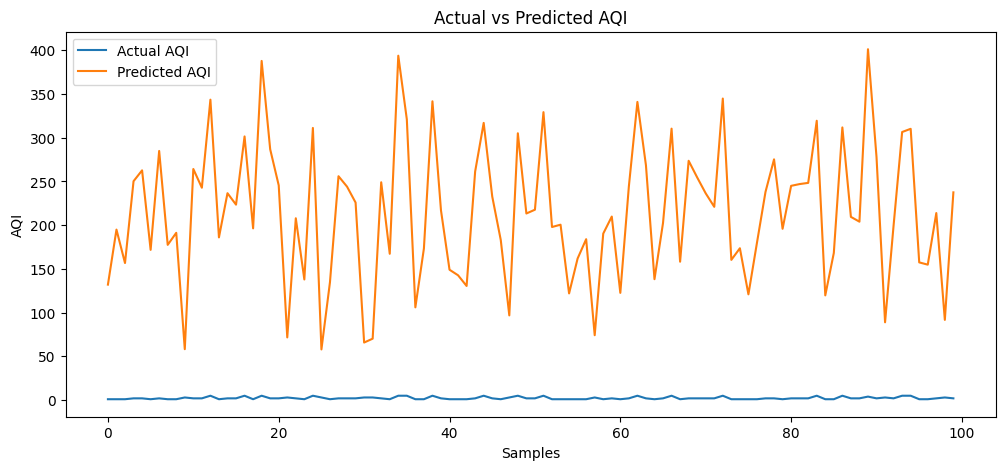

In [31]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label='Actual AQI')
plt.plot(y_pred_rf[:100], label='Predicted AQI')

plt.title("Actual vs Predicted AQI")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()

plt.show()

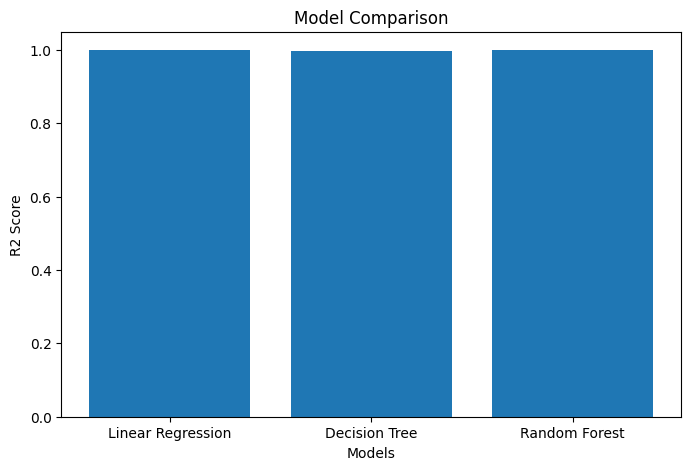

In [35]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

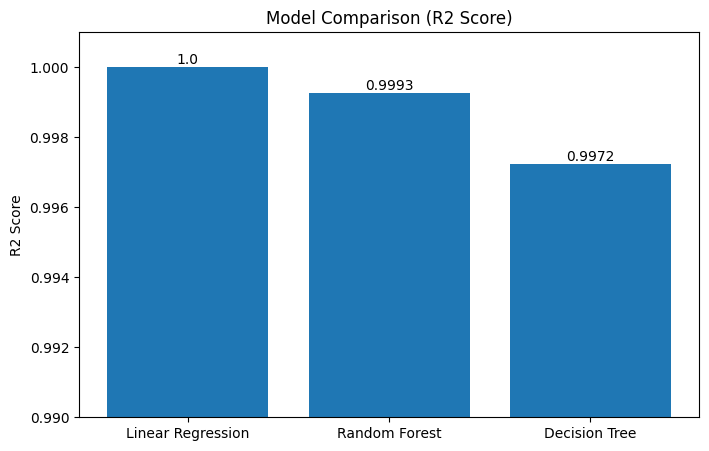

In [36]:
models = ['Linear Regression', 'Random Forest', 'Decision Tree']

scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_dt)
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, scores)

# Zoom Y-axis for visibility
plt.ylim(0.99, 1.001)

# Add score labels
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score,
        round(score, 4),
        ha='center',
        va='bottom'
    )

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")

plt.show()

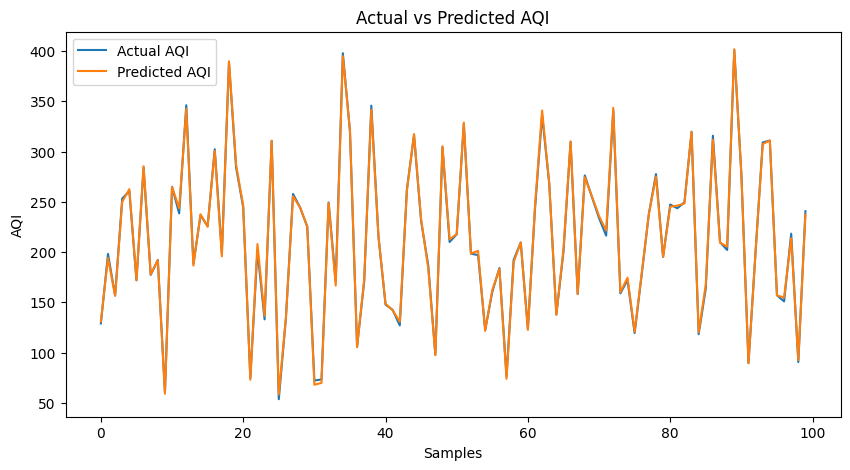

In [37]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual AQI")
plt.plot(y_pred_rf[:100], label="Predicted AQI")

plt.title("Actual vs Predicted AQI")
plt.xlabel("Samples")
plt.ylabel("AQI")

plt.legend()

plt.show()

In [38]:
# ==============================
# MODEL ACCURACY COMPARISON TABLE
# ==============================

model_names = [
    "Linear Regression",
    "Random Forest",
    "Decision Tree"
]

mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_rf),
    mean_absolute_error(y_test, y_pred_dt)
]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_dt)
]

accuracy_table = pd.DataFrame({
    "Model": model_names,
    "MAE": mae_scores,
    "R2 Score": r2_scores
})

print("\nMODEL PERFORMANCE TABLE\n")
print(accuracy_table)


MODEL PERFORMANCE TABLE

               Model           MAE  R2 Score
0  Linear Regression  6.164197e-14  1.000000
1      Random Forest  1.884890e+00  0.999262
2      Decision Tree  3.690168e+00  0.997241


In [39]:
accuracy_table.style.background_gradient(cmap='Blues')

,Model,MAE,R2 Score
0,Linear Regression,0.000000,1.000000
1,Random Forest,1.884890,0.999262
2,Decision Tree,3.690168,0.997241
